In [2]:
import torch
import torch.nn as nn
import numpy as np
import math
import copy
from tqdm.auto import tqdm
from typing import Any, Dict, Optional, Callable, Sequence
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from typing import Optional, Tuple, Union, Literal, List


# Functions

## Utils

In [16]:
sigmoid = nn.Sigmoid()
softmax = nn.Softmax(dim=1)

def get_device() -> torch.device:
  return torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

get_device()

device(type='cpu')

## Dataset functions

Split data

In [17]:
from sklearn.model_selection import train_test_split

def random_split_xy(
  X,
  y,
  val_frac: float = 0.1,
  test_frac: float = 0.2,
  seed: int = 0
):
  """
  Randomly split (X, y) into train/val/test using sklearn's train_test_split.

  Inputs:
    X: array-like, shape (n, d_x) (or any indexable array-like)
    y: array-like, shape (n, d_y) or (n,) or (n,1) or one-hot (n,C)
    val_frac: fraction of full data to use for validation
    test_frac: fraction of full data to use for test
    seed: random_state

  Returns:
    X_train, y_train, X_val, y_val, X_test, y_test
  """

  # 1) Split out test
  X_tmp, X_test, y_tmp, y_test = train_test_split(
    X,
    y,
    test_size=test_frac,
    random_state=seed,
    shuffle=True
  )

  # 2) Split tmp into train/val
  X_train, X_val, y_train, y_val = train_test_split(
    X_tmp,
    y_tmp,
    test_size=val_frac/(1-test_frac),
    random_state=seed,
    shuffle=True
  )

  return (
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
  )

Dataset

In [18]:
from torch.utils.data import Dataset, DataLoader

class TabularDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

## Models

In [19]:
class LinearModel(nn.Module):
  """
  Linear model (possibly multi-output).
  Input:  x: (B, d_in)
  Output: y_hat: (B, d_out)
  """
  def __init__(self,
               d_in: int,
               d_out: int = 1,
               bias: bool = True):
    super().__init__()
    self.linear = nn.Linear(d_in, d_out, bias=bias)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear(x)

class MLP(nn.Module):
  """
  MLP with user-specified hidden layer sizes.

  Input:  x: (B, d_in)
  Output: y_hat: (B, d_out)

  Example:
    model = MLP(d_in=10, d_hidden=[128, 64, 32], d_out=1)
  """
  def __init__(self,
               d_in: int,
               d_hidden: Sequence[int],
               d_out: int = 1,
               activation: str = "relu",
               dropout: float = 0.0,
               bias: bool = True):
    super().__init__()

    act = {
      "relu": nn.ReLU(),
      "tanh": nn.Tanh(),
      "sigmoid": nn.Sigmoid(),
    }.get(activation)

    if act is None:
      raise ValueError(f"Unknown activation: {activation}")

    dims = [d_in] + list(d_hidden) + [d_out]

    layers = []
    for i in range(len(dims) - 1):
      layers.append(nn.Linear(dims[i], dims[i + 1], bias=bias))
      if i < len(dims) - 2:  # not the last layer
        layers.append(act)
        if dropout > 0.0:
          layers.append(nn.Dropout(dropout))

    self.net = nn.Sequential(*layers)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.net(x)

import torch.nn.functional as F

class MF(torch.nn.Module):
    def __init__(self, n, m, rank):
        super(MF, self).__init__()
        self.U = torch.nn.Embedding(n, rank)
        self.V = torch.nn.Embedding(m, rank)

        with torch.no_grad():
          self.U.weight.copy_(F.normalize(self.U.weight, p=2, dim=1))
          self.V.weight.copy_(F.normalize(self.V.weight, p=2, dim=1))

    def forward(self, x):
        i = x[:,0]
        j = x[:,1]
        z = self.U(i.squeeze()) * self.V(j.squeeze())
        z = torch.sum(z, dim=1)
        return z[:,None]

## Training functions

Adam

In [20]:
from torch import optim

def fit_adam(*,
  model: nn.Module,
  train_data: Dataset,
  val_data: Dataset,
  batch_size: int,
  early_stop_patience: int,
  early_stop_tol: float = 0.0,
  eval_every: int = 100,
  lr: float = 1e-3,
  weight_decay: float = 0.0,
  n_steps: int = 10_000,
  loss_fn: Optional[Callable[[torch.Tensor, torch.Tensor], torch.Tensor]] = None,
  device: Optional[torch.device] = None,
  verbose: bool = True
) -> Dict[str, Any]:

  train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
  val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

  dev = device if device is not None else next(model.parameters()).device
  model.to(dev)
  opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

  history = []
  best_val = float("inf")
  best_state = copy.deepcopy(model.state_dict())
  bad_evals = 0

  last_train_loss = math.nan
  last_val_loss = math.nan

  @torch.no_grad()
  def eval_val():
    model.eval()
    tot, n = 0.0, 0
    for x, y in val_dataloader:
      x = x.to(dev)
      y = y.to(dev)
      pred = model(x)
      if loss_fn is None:
        raise ValueError("loss_fn must be provided when dataloaders yield (x, y).")
      loss = loss_fn(pred, y)
      bs = x.shape[0]
      tot += float(loss) * bs
      n += bs
    return tot / max(n, 1)

  step = 0
  epoch = 0
  stop = False

  pbar = tqdm(total=n_steps, disable=not verbose, desc="train", unit="step")
  try:
    while (not stop) and (step < n_steps):
      pbar.set_description(f"epoch {epoch}")

      for x, y in train_dataloader:
        step += 1

        model.train()
        opt.zero_grad(set_to_none=True)

        x = x.to(dev)
        y = y.to(dev)

        pred = model(x)
        if loss_fn is None:
          raise ValueError("loss_fn must be provided when dataloaders yield (x, y).")

        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()

        last_train_loss = float(loss.detach().cpu())

        do_eval = (step == 1) or (step % eval_every == 0) or (step == n_steps)
        if do_eval:
          last_val_loss = float(eval_val())
          history.append({
            "step": step,
            "train_loss": last_train_loss,
            "val_loss": last_val_loss,
          })

          if last_val_loss < best_val - early_stop_tol:
            best_val = last_val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_evals = 0
          else:
            bad_evals += 1
            if bad_evals >= early_stop_patience:
              stop = True
        else:
          history.append({
            "step": step,
            "train_loss": last_train_loss,
            "val_loss": math.nan,
          })

        # show latest train loss every step; val updates on eval steps (otherwise stays last value)
        pbar.set_postfix(
          train=f"{last_train_loss:.4g}" if math.isfinite(last_train_loss) else "nan",
          val=f"{last_val_loss:.4g}" if math.isfinite(last_val_loss) else "nan",
          best_val=f"{best_val:.4g}" if math.isfinite(best_val) else "inf",
          bad=bad_evals
        )
        pbar.update(1)

        if stop or (step >= n_steps):
          stop = True
          break

      epoch += 1
  finally:
    pbar.close()

  model.load_state_dict(best_state)
  return {"model": model, "history": history, "best_val_loss": best_val}

LBFGS

In [21]:
def fit_lbfgs(*,
  model: nn.Module,
  train_data: Dataset,
  val_data: Dataset,
  loss_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
  lr: float = 1.0,
  l2: float = 0.0,
  max_iter: int = 200,
  device: Optional[torch.device] = None
) -> Dict[str, Any]:
  """
  Full-batch L-BFGS with Strong Wolfe line search.
  - Runs the optimizer "normally" (single opt.step; iterations handled internally by LBFGS).
  - Manual L2: objective = loss_fn(...) + l2 * sum(||p||^2).
  - Evaluates val once at the end.
  - Promotes model + float tensors to float64 (recommended for LBFGS).
  """

  def _to_tensor(a):
    if torch.is_tensor(a):
      return a
    return torch.as_tensor(a)

  def _get_full_xy(ds: Dataset):
    if hasattr(ds, "X") and hasattr(ds, "y"):
      return _to_tensor(getattr(ds, "X")), _to_tensor(getattr(ds, "y"))

    x0, y0 = ds[0]
    x0t, y0t = _to_tensor(x0), _to_tensor(y0)
    if hasattr(x0t, "shape") and len(getattr(x0t, "shape", ())) > 0 and x0t.shape[0] == len(ds):
      return x0t, y0t

    xs, ys = [], []
    for i in range(len(ds)):
      xi, yi = ds[i]
      xs.append(_to_tensor(xi))
      ys.append(_to_tensor(yi))
    return torch.stack(xs, dim=0), torch.stack(ys, dim=0)

  dev = device if device is not None else next(model.parameters()).device
  model.to(dev)
  model.double()

  x_tr, y_tr = _get_full_xy(train_data)
  x_va, y_va = _get_full_xy(val_data)

  # Only convert to double if the tensor is floating point. Indices should remain long.
  x_tr = x_tr.to(dev)
  if x_tr.is_floating_point():
      x_tr = x_tr.to(dtype=torch.double)

  y_tr = y_tr.to(dev)
  if y_tr.is_floating_point():
    y_tr = y_tr.to(dtype=torch.double)

  x_va = x_va.to(dev)
  if x_va.is_floating_point():
      x_va = x_va.to(dtype=torch.double)

  y_va = y_va.to(dev)
  if y_va.is_floating_point():
    y_va = y_va.to(dtype=torch.double)

  def _l2_penalty() -> torch.Tensor:
    if l2 == 0.0:
      return torch.zeros((), device=dev, dtype=torch.double)
    s = torch.zeros((), device=dev, dtype=torch.double)
    for p in model.parameters():
      if p.requires_grad:
        s = s + p.pow(2).sum()
    return l2 * s

  opt = optim.LBFGS(
    model.parameters(),
    lr=lr,
    max_iter=max_iter,
    line_search_fn="strong_wolfe"
  )

  def closure():
    opt.zero_grad(set_to_none=True)
    model.train()
    pred = model(x_tr)
    data_loss = loss_fn(pred, y_tr)
    obj = data_loss + _l2_penalty()
    obj.backward()
    return obj

  # Run LBFGS "normally": max_iter is handled inside this call.
  opt.step(closure)

  @torch.no_grad()
  def eval_once(x, y):
    model.eval()
    pred = model(x)
    data_loss = loss_fn(pred, y)
    obj = data_loss + _l2_penalty()
    return float(data_loss.detach().cpu()), float(obj.detach().cpu())

  train_loss, train_obj = eval_once(x_tr, y_tr)
  val_loss, val_obj = eval_once(x_va, y_va)

  return {
    "model": model,
    "train_loss": train_loss,  # data loss only
    "train_obj": train_obj,    # data loss + manual L2
    "val_loss": val_loss,      # data loss only
    "val_obj": val_obj         # data loss + manual L2
  }

## Prediction

In [22]:
@torch.no_grad()
def predict(*,
  model: nn.Module,
  data: Dataset,
  batch_size: int = 128,
  device: Optional[torch.device] = None,
  return_targets: bool = True,
  to_numpy: bool = False
) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
  """
  Runs model on `data` and returns predictions (optionally with targets).

  Assumes each batch yields either:
    - x
    - (x, y)
  """
  dev = device if device is not None else next(model.parameters()).device
  model.to(dev)
  model.eval()

  loader = DataLoader(data, batch_size=batch_size, shuffle=False)

  preds = []
  targets = []

  for batch in loader:
    if isinstance(batch, (tuple, list)) and len(batch) == 2:
      x, y = batch
    else:
      x, y = batch, None

    x = x.to(dev)
    y_hat = model(x)

    preds.append(y_hat.detach().cpu())

    if return_targets:
      if y is None:
        raise ValueError("return_targets=True but dataset/dataloader did not yield (x, y).")
      targets.append(y.detach().cpu())

  y_hat_all = torch.cat(preds, dim=0) if len(preds) > 0 else torch.empty(0)

  if not return_targets:
    return y_hat_all.numpy() if to_numpy else y_hat_all

  y_all = torch.cat(targets, dim=0) if len(targets) > 0 else torch.empty(0)
  if to_numpy:
    return y_hat_all.numpy(), y_all.numpy()

  return y_hat_all, y_all

## Eval functions

In [23]:
from sklearn.metrics import (
  accuracy_score,
  precision_recall_fscore_support,
  log_loss,
  roc_auc_score,
  mean_squared_error,
  mean_absolute_error,
  brier_score_loss,
)

from sklearn.calibration import calibration_curve
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

_EPS = 1e-12

def _to_numpy(x: Any) -> np.ndarray:
  # Torch -> numpy (without importing torch)
  if hasattr(x, "detach") and callable(x.detach):
    x = x.detach()
  if hasattr(x, "cpu") and callable(x.cpu):
    x = x.cpu()
  if hasattr(x, "numpy") and callable(x.numpy):
    return np.asarray(x.numpy())
  return np.asarray(x)


def _ensure_2d(a: np.ndarray) -> np.ndarray:
  a = np.asarray(a)
  if a.ndim == 1:
    return a.reshape(-1, 1)
  if a.ndim != 2:
    raise ValueError(f"Expected 2D array (or 1D), got shape {a.shape}")
  return a


def _softmax(logits: np.ndarray, axis: int = 1) -> np.ndarray:
  logits = np.asarray(logits, dtype=np.float64)
  m = np.max(logits, axis=axis, keepdims=True)
  exps = np.exp(logits - m)
  return exps / np.clip(np.sum(exps, axis=axis, keepdims=True), _EPS, None)


def _sigmoid(z: np.ndarray) -> np.ndarray:
  z = np.asarray(z, dtype=np.float64)
  out = np.empty_like(z, dtype=np.float64)
  pos = z >= 0
  neg = ~pos
  out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
  ez = np.exp(z[neg])
  out[neg] = ez / (1.0 + ez)
  return out


def _labels_from_y(y: np.ndarray) -> np.ndarray:
  y = _ensure_2d(y)
  if y.shape[1] == 1:
    return y.reshape(-1).astype(int)
  return np.argmax(y, axis=1).astype(int)


def _onehot_from_labels(labels: np.ndarray, n_classes: int) -> np.ndarray:
  labels = labels.astype(int)
  oh = np.zeros((labels.shape[0], n_classes), dtype=int)
  oh[np.arange(labels.shape[0]), labels] = 1
  return oh


def _pearson_1d(a: np.ndarray, b: np.ndarray) -> float:
  a = np.asarray(a, dtype=np.float64).reshape(-1)
  b = np.asarray(b, dtype=np.float64).reshape(-1)
  try:
    r, _ = pearsonr(a, b)
    return float(r)
  except Exception:
    return float("nan")


def _spearman_1d(a: np.ndarray, b: np.ndarray) -> float:
  a = np.asarray(a, dtype=np.float64).reshape(-1)
  b = np.asarray(b, dtype=np.float64).reshape(-1)
  try:
    res = spearmanr(a, b)
    corr = getattr(res, "correlation", res)
    return float(corr)
  except Exception:
    return float("nan")


def _calibration_stats_binary(
  y_true01: np.ndarray,
  p_pos: np.ndarray,
  n_bins: int = 10
) -> Tuple[float, List[float], List[float]]:
  """
  Returns:
    - avg_abs_gap: mean(|prob_true - prob_pred|) across non-empty bins
    - prob_pred_list
    - prob_true_list
  """
  y_true01 = np.asarray(y_true01).astype(int).reshape(-1)
  p_pos = np.asarray(p_pos, dtype=np.float64).reshape(-1)
  p_pos = np.clip(p_pos, _EPS, 1.0 - _EPS)

  # calibration_curve can fail if only one class present
  prob_true, prob_pred = calibration_curve(
    y_true01,
    p_pos,
    n_bins=n_bins,
    strategy="quantile"
  )
  gap = np.abs(prob_true - prob_pred)
  avg_abs_gap = float(np.mean(gap)) if gap.size > 0 else float("nan")
  return avg_abs_gap, [float(x) for x in prob_pred], [float(x) for x in prob_true]


def binary_classification_metrics(
  y_score: Any,
  y: Any,
  threshold: float = 0.5,
  input_type: str = "probs",  # "probs" or "logits"
  pos_index: int = 1,
  n_calib_bins: int = 10
) -> Dict[str, float]:
  """
  Binary classification metrics.

  Inputs:
    y_score: (n,1) prob/logit for positive class OR (n,2) probs/logits for both classes.
    y: (n,1) labels in {0,1} OR (n,2) one-hot.
  Returns:
    dict with:
      acc/precision/recall/f1 at threshold,
      cross_entropy, auc,
      brier,
      calib_abs_gap (quantile bins),
      calib_curve_prob_pred, calib_curve_prob_true (lists)
  """
  ys = _ensure_2d(_to_numpy(y_score))
  yy = _ensure_2d(_to_numpy(y))
  y_true = _labels_from_y(yy)

  if input_type not in ("probs", "logits"):
    raise ValueError("input_type must be 'probs' or 'logits'")

  if ys.shape[1] == 1:
    if input_type == "probs":
      p_pos = ys.reshape(-1).astype(np.float64)
    else:
      p_pos = _sigmoid(ys.reshape(-1))
  elif ys.shape[1] == 2:
    if pos_index not in (0, 1):
      raise ValueError("pos_index must be 0 or 1 for binary (n,2) scores.")
    if input_type == "probs":
      probs2 = ys.astype(np.float64)
    else:
      probs2 = _softmax(ys, axis=1)
    p_pos = probs2[:, pos_index]
  else:
    raise ValueError(f"Binary expects y_score with 1 or 2 columns, got {ys.shape[1]}")

  p_pos = np.clip(p_pos, _EPS, 1.0 - _EPS)
  y_pred = (p_pos >= threshold).astype(int)

  tp = int(np.sum((y_true == 1) & (y_pred == 1)))
  fp = int(np.sum((y_true == 0) & (y_pred == 1)))
  fn = int(np.sum((y_true == 1) & (y_pred == 0)))
  tn = int(np.sum((y_true == 0) & (y_pred == 0)))

  precision = 0.0 if (tp + fp) == 0 else tp / (tp + fp)
  recall = 0.0 if (tp + fn) == 0 else tp / (tp + fn)
  f1 = 0.0 if (precision + recall) == 0 else 2.0 * precision * recall / (precision + recall)
  acc = (tp + tn) / max(1, (tp + tn + fp + fn))

  out: Dict[str, float] = {}
  out[f"acc@{threshold:g}"] = float(acc)
  out[f"precision@{threshold:g}"] = float(precision)
  out[f"recall@{threshold:g}"] = float(recall)
  out[f"f1@{threshold:g}"] = float(f1)

  # threshold-free metrics
  try:
    out["cross_entropy"] = float(log_loss(y_true, p_pos, labels=[0, 1]))
  except Exception:
    out["cross_entropy"] = float("nan")

  try:
    out["auc"] = float(roc_auc_score(y_true, p_pos))
  except Exception:
    out["auc"] = float("nan")

  # calibration: Brier + calibration curve gap
  try:
    out["brier"] = float(brier_score_loss(y_true, p_pos))
  except Exception:
    out["brier"] = float("nan")

  try:
    calib_gap, prob_pred, prob_true = _calibration_stats_binary(y_true, p_pos, n_bins=n_calib_bins)
    out["calib_abs_gap"] = float(calib_gap)
    # "calibration curves" as points: (prob_pred, prob_true)
    out["calib_curve_prob_pred"] = prob_pred
    out["calib_curve_prob_true"] = prob_true
  except Exception:
    out["calib_abs_gap"] = float("nan")
    out["calib_curve_prob_pred"] = []
    out["calib_curve_prob_true"] = []

  return out


def multiclass_classification_metrics(
  y_score: Any,
  y: Any,
  input_type: str = "probs",     # "probs" or "logits"
  multi_class_auc: str = "ovr",  # "ovr" or "ovo"
  n_calib_bins: int = 10
) -> Dict[str, float]:
  """
  Multinomial (single-label) classification metrics.

  Inputs:
    y_score: (n,C) probs or logits
    y: (n,1) integer labels OR (n,C) one-hot
  Returns:
    dict with:
      acc,
      precision/recall/f1 (macro/micro/weighted),
      cross_entropy,
      auc_(macro/micro/weighted),
      brier (multiclass),
      calib_abs_gap_(macro/micro/weighted) computed via OVR calibration curves,
      plus calibration curve points (per-class + micro).
  """
  ys = _ensure_2d(_to_numpy(y_score))
  yy = _ensure_2d(_to_numpy(y))
  y_true = _labels_from_y(yy)

  if ys.shape[1] < 2:
    raise ValueError(f"Multiclass expects y_score with C>=2 columns, got {ys.shape[1]}")

  if input_type not in ("probs", "logits"):
    raise ValueError("input_type must be 'probs' or 'logits'")

  if multi_class_auc not in ("ovr", "ovo"):
    raise ValueError("multi_class_auc must be 'ovr' or 'ovo'")

  if input_type == "probs":
    probs = ys.astype(np.float64)
  else:
    probs = _softmax(ys, axis=1)

  probs = np.clip(probs, _EPS, 1.0)
  probs = probs / np.clip(probs.sum(axis=1, keepdims=True), _EPS, None)

  n_classes = probs.shape[1]
  y_pred = np.argmax(probs, axis=1)
  y_onehot = _onehot_from_labels(y_true, n_classes)

  out: Dict[str, float] = {}
  out["acc"] = float(accuracy_score(y_true, y_pred))

  for avg in ("macro", "micro", "weighted"):
    p, r, f, _ = precision_recall_fscore_support(
      y_true,
      y_pred,
      average=avg,
      zero_division=0
    )
    out[f"precision_{avg}"] = float(p)
    out[f"recall_{avg}"] = float(r)
    out[f"f1_{avg}"] = float(f)

  # Cross-entropy
  try:
    out["cross_entropy"] = float(log_loss(y_true, probs, labels=list(range(n_classes))))
  except Exception:
    out["cross_entropy"] = float("nan")

  # AUC macro/weighted (sklearn multiclass)
  for avg in ("macro", "weighted"):
    try:
      out[f"auc_{avg}"] = float(
        roc_auc_score(y_true, probs, multi_class=multi_class_auc, average=avg)
      )
    except Exception:
      out[f"auc_{avg}"] = float("nan")

  # AUC micro via flattening (robust across sklearn versions)
  try:
    out["auc_micro"] = float(roc_auc_score(y_onehot.ravel(), probs.ravel()))
  except Exception:
    out["auc_micro"] = float("nan")

  # Multiclass Brier score: mean over samples of sum_k (p_k - y_k)^2
  try:
    out["brier"] = float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))
  except Exception:
    out["brier"] = float("nan")

  # Calibration (OVR per class + aggregated gaps)
  gaps_by_class: List[float] = []
  curve_pred_by_class: List[List[float]] = []
  curve_true_by_class: List[List[float]] = []

  class_counts = np.bincount(y_true, minlength=n_classes).astype(np.float64)
  class_weights = class_counts / max(1.0, float(np.sum(class_counts)))

  for k in range(n_classes):
    yk = y_onehot[:, k]
    pk = probs[:, k]
    try:
      gap_k, prob_pred, prob_true = _calibration_stats_binary(yk, pk, n_bins=n_calib_bins)
      gaps_by_class.append(float(gap_k))
      curve_pred_by_class.append(prob_pred)
      curve_true_by_class.append(prob_true)
    except Exception:
      gaps_by_class.append(float("nan"))
      curve_pred_by_class.append([])
      curve_true_by_class.append([])

  out["calib_abs_gap_by_class"] = [float(x) if np.isfinite(x) else float("nan") for x in gaps_by_class]
  out["calib_curve_prob_pred_by_class"] = curve_pred_by_class
  out["calib_curve_prob_true_by_class"] = curve_true_by_class

  # macro / weighted gaps (ignore NaNs)
  gaps_arr = np.asarray(gaps_by_class, dtype=np.float64)
  out["calib_abs_gap_macro"] = float(np.nanmean(gaps_arr)) if np.isfinite(gaps_arr).any() else float("nan")

  try:
    # Weighted average ignoring NaNs by re-normalizing weights over finite gaps
    finite = np.isfinite(gaps_arr)
    if not finite.any():
      out["calib_abs_gap_weighted"] = float("nan")
    else:
      w = class_weights[finite]
      w = w / np.clip(np.sum(w), _EPS, None)
      out["calib_abs_gap_weighted"] = float(np.sum(w * gaps_arr[finite]))
  except Exception:
    out["calib_abs_gap_weighted"] = float("nan")

  # micro calibration: flatten one-hot and probs, then do binary calibration
  try:
    gap_micro, prob_pred_micro, prob_true_micro = _calibration_stats_binary(
      y_onehot.ravel(),
      probs.ravel(),
      n_bins=n_calib_bins
    )
    out["calib_abs_gap_micro"] = float(gap_micro)
    out["calib_curve_prob_pred_micro"] = prob_pred_micro
    out["calib_curve_prob_true_micro"] = prob_true_micro
  except Exception:
    out["calib_abs_gap_micro"] = float("nan")
    out["calib_curve_prob_pred_micro"] = []
    out["calib_curve_prob_true_micro"] = []

  return out


def regression_metrics(
  y_hat: Any,
  y: Any
) -> Dict[str, float]:
  """
  Regression metrics with support for multi-output regression.

  Inputs:
    y_hat: (n,d) predictions (or (n,1))
    y: (n,d) targets (or (n,1))
  Returns:
    dict with overall means + per-dimension arrays:
      mse, rmse, mae, pearson, spearman
  """
  yp = _ensure_2d(_to_numpy(y_hat)).astype(np.float64)
  yt = _ensure_2d(_to_numpy(y)).astype(np.float64)

  if yp.shape != yt.shape:
    raise ValueError(f"y_hat and y must have same shape. Got {yp.shape} vs {yt.shape}")

  mse_by = mean_squared_error(yt, yp, multioutput="raw_values")
  mae_by = mean_absolute_error(yt, yp, multioutput="raw_values")
  rmse_by = np.sqrt(np.maximum(mse_by, 0.0))

  pearson_by = []
  spearman_by = []
  for j in range(yt.shape[1]):
    pearson_by.append(_pearson_1d(yt[:, j], yp[:, j]))
    spearman_by.append(_spearman_1d(yt[:, j], yp[:, j]))

  mse_by = np.asarray(mse_by, dtype=np.float64)
  rmse_by = np.asarray(rmse_by, dtype=np.float64)
  mae_by = np.asarray(mae_by, dtype=np.float64)
  pearson_by = np.asarray(pearson_by, dtype=np.float64)
  spearman_by = np.asarray(spearman_by, dtype=np.float64)

  out: Dict[str, float] = {}
  out["mse"] = float(np.nanmean(mse_by))
  out["rmse"] = float(np.nanmean(rmse_by))
  out["mae"] = float(np.nanmean(mae_by))
  out["pearson"] = float(np.nanmean(pearson_by))
  out["spearman"] = float(np.nanmean(spearman_by))

  out["mse_by_dim"] = [float(x) for x in mse_by]
  out["rmse_by_dim"] = [float(x) for x in rmse_by]
  out["mae_by_dim"] = [float(x) for x in mae_by]
  out["pearson_by_dim"] = [float(x) if np.isfinite(x) else float("nan") for x in pearson_by]
  out["spearman_by_dim"] = [float(x) if np.isfinite(x) else float("nan") for x in spearman_by]

  return out

## Outputsa
def plot_confusion_matrix(
  y: Any,
  y_score: Any = None,
  y_pred: Any = None,
  task: str = "multiclass",          # "binary" or "multiclass"
  input_type: str = "probs",         # "probs" or "logits" (only used if y_score is given)
  threshold: float = 0.5,            # only used for binary if y_score is given
  pos_index: int = 1,                # only used for binary when y_score has shape (n,2)
  normalize: Optional[str] = None,   # None, "true", "pred", "all"
  labels: Optional[List[int]] = None,
  display_labels: Optional[List[str]] = None,
  ax: Optional[Any] = None,
  title: Optional[str] = None
) -> Tuple[np.ndarray, Any, Any]:
  """
  Plot and return confusion matrix.

  You can provide either:
    - y_pred (preferred if already computed), or
    - y_score (logits/probs) to derive y_pred

  Inputs:
    y: (n,1) labels or (n,C) one-hot
    y_score: (n,1)/(n,2) for binary or (n,C) for multiclass
    y_pred: (n,1) predicted labels (or (n,) is fine)
  Returns:
    cm: np.ndarray
    fig, ax
  """
  yy = _ensure_2d(_to_numpy(y))
  y_true = _labels_from_y(yy)

  if y_pred is None:
    if y_score is None:
      raise ValueError("Provide either y_pred or y_score.")
    ys = _ensure_2d(_to_numpy(y_score))

    if task == "binary":
      if input_type not in ("probs", "logits"):
        raise ValueError("input_type must be 'probs' or 'logits'")

      if ys.shape[1] == 1:
        p_pos = ys.reshape(-1).astype(np.float64)
        if input_type == "logits":
          p_pos = _sigmoid(p_pos)
      elif ys.shape[1] == 2:
        if pos_index not in (0, 1):
          raise ValueError("pos_index must be 0 or 1 for binary (n,2) scores.")
        probs2 = ys.astype(np.float64) if input_type == "probs" else _softmax(ys, axis=1)
        p_pos = probs2[:, pos_index]
      else:
        raise ValueError(f"Binary expects y_score with 1 or 2 columns, got {ys.shape[1]}")

      y_pred_lbl = (p_pos >= threshold).astype(int)

    elif task == "multiclass":
      if ys.shape[1] < 2:
        raise ValueError(f"Multiclass expects y_score with C>=2 columns, got {ys.shape[1]}")
      probs = ys.astype(np.float64) if input_type == "probs" else _softmax(ys, axis=1)
      y_pred_lbl = np.argmax(probs, axis=1).astype(int)

    else:
      raise ValueError("task must be 'binary' or 'multiclass'")
  else:
    yp = _to_numpy(y_pred)
    if yp.ndim == 2 and yp.shape[1] == 1:
      yp = yp.reshape(-1)
    y_pred_lbl = yp.astype(int)

  cm = confusion_matrix(
    y_true,
    y_pred_lbl,
    labels=labels,
    normalize=normalize
  )

  if ax is None:
    fig, ax = plt.subplots()
  else:
    fig = ax.figure

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
  disp.plot(ax=ax, values_format=".2f" if normalize else "d", colorbar=False)

  if title is None:
    base = "Confusion Matrix"
    if normalize:
      base += f" (normalize={normalize})"
    title = base
  ax.set_title(title)
  fig.tight_layout()

  return cm, fig, ax


def compare_models(
  y_hats: List[Any],
  names: List[str],
  y: Any,
  task: str,                      # "binary", "multiclass", "regression"
  input_type: str = "probs",       # for classification: "probs" or "logits"
  threshold: float = 0.5,          # for binary threshold metrics
  pos_index: int = 1,              # binary (n,2) case
  multi_class_auc: str = "ovr",    # multiclass AUC mode
  n_calib_bins: int = 10,
  metrics: Optional[List[str]] = None,
  sort_by: Optional[str] = None,
  ascending: bool = False,
  print_table: bool = True
) -> pd.DataFrame:
  """
  Compare multiple models by computing metrics for each and printing a table.

  Inputs:
    y_hats: list of predictions (each can be torch/numpy). Shapes:
      - binary: (n,1) or (n,2) probs/logits
      - multiclass: (n,C) probs/logits
      - regression: (n,d)
    names: list of model names (same length as y_hats)
    y: ground-truth (2D, but 1D tolerated)
    metrics: optional list of column names to keep in the output table
    sort_by: optional metric column to sort by
  Returns:
    pandas DataFrame
  """
  if len(y_hats) != len(names):
    raise ValueError("y_hats and names must have same length")

  rows = []
  for yh, name in zip(y_hats, names):
    if task == "binary":
      d = binary_classification_metrics(
        y_score=yh,
        y=y,
        threshold=threshold,
        input_type=input_type,
        pos_index=pos_index,
        n_calib_bins=n_calib_bins
      )
      # Keep a sane default subset if caller didn't specify
      default_cols = [
        f"acc@{threshold:g}",
        f"f1@{threshold:g}",
        f"precision@{threshold:g}",
        f"recall@{threshold:g}",
        "auc",
        "cross_entropy",
        "brier",
        "calib_abs_gap",
      ]
    elif task == "multiclass":
      d = multiclass_classification_metrics(
        y_score=yh,
        y=y,
        input_type=input_type,
        multi_class_auc=multi_class_auc,
        n_calib_bins=n_calib_bins
      )
      default_cols = [
        "acc",
        "f1_macro",
        "f1_weighted",
        "precision_macro",
        "precision_weighted",
        "recall_macro",
        "precision_macro",
        "auc_macro",
        "auc_weighted",
        "cross_entropy",
        "brier",
        "calib_abs_gap_macro",
        "calib_abs_gap_weighted"
      ]
    elif task == "regression":
      d = regression_metrics(y_hat=yh, y=y)
      default_cols = [
        "rmse",
        "mae",
        "mse",
        "pearson",
        "spearman",
      ]
    else:
      raise ValueError("task must be 'binary', 'multiclass', or 'regression'")

    row = {"model": name}
    row.update(d)
    rows.append(row)

  df = pd.DataFrame(rows)

  # If user didn't pass a metric list, keep defaults (plus model)
  if metrics is None:
    if len(rows) > 0:
      if task in ("binary", "multiclass"):
        keep = ["model"] + [c for c in default_cols if c in df.columns]
      else:
        keep = ["model"] + [c for c in default_cols if c in df.columns]
      df = df.loc[:, keep]
  else:
    keep = ["model"] + [m for m in metrics if m in df.columns]
    df = df.loc[:, keep]

  if sort_by is not None and sort_by in df.columns:
    df = df.sort_values(sort_by, ascending=bool(ascending)).reset_index(drop=True)
  else:
    df = df.reset_index(drop=True)

  if print_table:
    # Print nicely without scientific spam
    with pd.option_context("display.max_columns", None, "display.width", 200):
      print(df.to_string(index=False))

  return df

# Regression

Generate data

In [ ]:
from sklearn.datasets import make_regression

X, Y = make_regression(n_samples=10000, n_features=30, noise=1, random_state=42)

In [ ]:
X, Y = torch.tensor(X, dtype=torch.float32), torch.tensor(Y[:,None], dtype=torch.float32)

(X_train, Y_train,
 X_val, Y_val,
 X_test, Y_test) = random_split_xy(X, Y)

train_data = TabularDataset(X_train, Y_train)
val_data = TabularDataset(X_val, Y_val)
test_data = TabularDataset(X_test, Y_test)

Sandbox

In [ ]:
batch_size = 128
early_stop_patience = 5
early_stop_tol = 0
eval_every = 10
n_epochs = 1000
loss_fn = nn.MSELoss()

lr = 1e-2
weight_decay = 0.001

In [ ]:
model = LinearModel(d_in=X.shape[1], d_out=Y.shape[1])
train_dataloader = DataLoader(train_data, batch_size=128, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=128, shuffle=False)

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
hist = []

for epoch in tqdm(range(n_epochs)):
  for batch in train_dataloader:
    model.zero_grad()
    x, y = batch
    loss = loss_fn(model(x), y)
    hist.append(loss.item())
    loss.backward()
    optimizer.step()

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
np.min(hist)

np.float64(0.5725356936454773)

(0.5, 1.5)

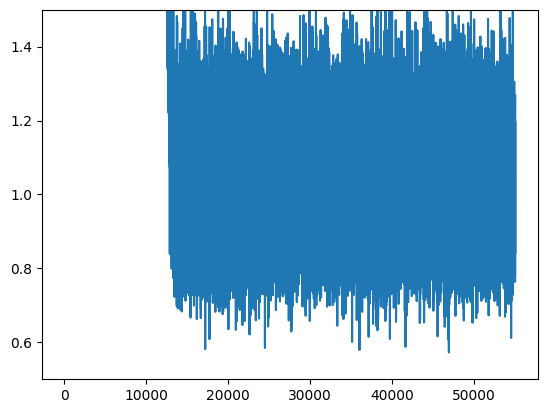

In [ ]:
plt.plot(hist)
plt.ylim(.5,1.5)

In [ ]:
preds = []
model.eval()
for batch in train_dataloader:
  if isinstance(batch, (tuple, list)) and len(batch) == 2:
    x, y = batch
  else:
    x, y = batch, None

  y_hat = model(x)

  preds.append(y_hat.detach().cpu())

y_hat_all = torch.cat(preds, dim=0) if len(preds) > 0 else torch.empty(0)

In [ ]:
len(preds)

55

Training

In [ ]:
batch_size = 128
early_stop_patience = 5
early_stop_tol = 0
eval_every = 100
n_steps = 100_000
loss_fn = nn.MSELoss()

lr = 1e-1
weight_decay = 0.0

In [ ]:
#linear_reg = LinearModel(d_in=X.shape[1], d_out=Y.shape[1])
#linear_reg.linear.weight, linear_reg.linear.bias

In [ ]:
output1 = fit_adam(model = LinearModel(d_in=X.shape[1], d_out=Y.shape[1]),
                   train_data = train_data,
                   val_data = val_data,
                   batch_size = batch_size,
                   early_stop_patience = early_stop_patience,
                   early_stop_tol = early_stop_tol,
                   eval_every = eval_every,
                   lr = lr,
                   weight_decay = weight_decay,
                   n_steps = n_steps,
                   loss_fn = loss_fn)

train:   0%|          | 0/100000 [00:00<?, ?step/s]

In [ ]:
output2 = fit_adam(model = MLP(d_in=X.shape[1],
                               d_hidden = [100],
                               activation='relu',
                               d_out=Y.shape[1]),
                   train_data = train_data,
                   val_data = val_data,
                   batch_size = batch_size,
                   early_stop_patience = early_stop_patience,
                   early_stop_tol = early_stop_tol,
                   eval_every = eval_every,
                   lr = lr/100,
                   weight_decay = weight_decay,
                   n_steps = n_steps,
                   loss_fn = loss_fn)

train:   0%|          | 0/100000 [00:00<?, ?step/s]

In [ ]:
output3 = fit_lbfgs(model = LinearModel(d_in=X.shape[1], d_out=Y.shape[1]),
                    train_data = train_data,
                    val_data = val_data,
                    loss_fn = loss_fn)
output3['model'] = output3['model'].float()

In [ ]:
y_hats = [predict(model=output1['model'], data=test_data)[0],
          predict(model=output2['model'], data=test_data)[0],
          predict(model=output3['model'], data=test_data)[0]]

compare_models(y_hats = y_hats,
               names = ['linear', 'mlp', 'lbfgs'],
               y = Y_test,
               task = 'regression')

 model     rmse      mae      mse  pearson  spearman
linear 1.000982 0.800860 1.001966 0.999985  0.999978
   mlp 1.859514 1.427556 3.457791 0.999949  0.999924
 lbfgs 1.002087 0.800804 1.004178 0.999985  0.999979


,model,rmse,mae,mse,pearson,spearman
0,linear,1.000982,0.800860,1.001966,0.999985,0.999978
1,mlp,1.859514,1.427556,3.457791,0.999949,0.999924
2,lbfgs,1.002087,0.800804,1.004178,0.999985,0.999979


In [ ]:
y_hats = [predict(model=output1['model'], data=val_data)[0],
          predict(model=output2['model'], data=val_data)[0],
          predict(model=output3['model'], data=val_data)[0]]

compare_models(y_hats = y_hats,
               names = ['linear', 'mlp', 'lbfgs'],
               y = Y_val,
               task = 'regression')

 model     rmse      mae      mse  pearson  spearman
linear 1.027771 0.800825 1.056312 0.999985  0.999977
   mlp 1.966798 1.494743 3.868294 0.999947  0.999915
 lbfgs 1.029260 0.802247 1.059376 0.999985  0.999977


,model,rmse,mae,mse,pearson,spearman
0,linear,1.027771,0.800825,1.056312,0.999985,0.999977
1,mlp,1.966798,1.494743,3.868294,0.999947,0.999915
2,lbfgs,1.029260,0.802247,1.059376,0.999985,0.999977


# Binary Classification

In [ ]:
from sklearn.datasets import make_classification
X, Y = make_classification(n_samples=10000, random_state=42)

X, Y = torch.tensor(X, dtype=torch.float32), torch.tensor(Y[:,None], dtype=torch.float32)

(X_train, Y_train,
 X_val, Y_val,
 X_test, Y_test) = random_split_xy(X, Y)

train_data = TabularDataset(X_train, Y_train)
val_data = TabularDataset(X_val, Y_val)
test_data = TabularDataset(X_test, Y_test)

#Y_train = Y_train.long()
#Y_val = Y_val.long()
#Y_test = Y_test.long()

X_train.shape, Y_train.shape

(torch.Size([7000, 20]), torch.Size([7000, 1]))

Training

In [ ]:
batch_size = 128
early_stop_patience = 5
early_stop_tol = 0
eval_every = 100
n_steps = 100_000
loss_fn = nn.BCEWithLogitsLoss()

lr = 1e-1
weight_decay = 0.0

In [ ]:
model = LinearModel(d_in=X.shape[1], d_out=Y.shape[1])
p = model(X_train)
loss_fn(p, Y_train)

tensor(0.7008, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [ ]:
output1 = fit_adam(model = LinearModel(d_in=X.shape[1], d_out=Y.shape[1]),
                   train_data = train_data,
                   val_data = val_data,
                   batch_size = batch_size,
                   early_stop_patience = early_stop_patience,
                   early_stop_tol = early_stop_tol,
                   eval_every = eval_every,
                   lr = lr,
                   weight_decay = weight_decay,
                   n_steps = n_steps,
                   loss_fn = loss_fn)

train:   0%|          | 0/100000 [00:00<?, ?step/s]

In [ ]:
output2 = fit_adam(model = MLP(d_in=X.shape[1],
                               d_hidden = [100],
                               activation='relu',
                               d_out=Y.shape[1]),
                   train_data = train_data,
                   val_data = val_data,
                   batch_size = batch_size,
                   early_stop_patience = early_stop_patience,
                   early_stop_tol = early_stop_tol,
                   eval_every = eval_every,
                   lr = lr/100,
                   weight_decay = weight_decay,
                   n_steps = n_steps,
                   loss_fn = loss_fn)

train:   0%|          | 0/100000 [00:00<?, ?step/s]

In [ ]:
output3 = fit_lbfgs(model = LinearModel(d_in=X.shape[1], d_out=Y.shape[1]),
                    train_data = train_data,
                    val_data = val_data,
                    loss_fn = loss_fn)
output3['model'] = output3['model'].float()

In [ ]:
y_hats = [predict(model=output1['model'], data=test_data)[0],
          predict(model=output2['model'], data=test_data)[0],
          predict(model=output3['model'], data=test_data)[0]]
for i,y_hat in enumerate(y_hats):
  y_hats[i] = sigmoid(y_hat)

compare_models(y_hats = y_hats,
               names = ['linear', 'mlp', 'lbfgs'],
               y = Y_test,
               task = 'binary')

 model  acc@0.5   f1@0.5  precision@0.5  recall@0.5      auc  cross_entropy    brier  calib_abs_gap
linear    0.879 0.881139       0.884615    0.877691 0.939585       0.319796 0.092980       0.019171
   mlp    0.927 0.929605       0.916350    0.943249 0.952268       0.273921 0.064472       0.035131
 lbfgs    0.879 0.880906       0.886139    0.875734 0.942565       0.308973 0.089454       0.019383


,model,acc@0.5,f1@0.5,precision@0.5,recall@0.5,auc,cross_entropy,brier,calib_abs_gap
0,linear,0.879,0.881139,0.884615,0.877691,0.939585,0.319796,0.092980,0.019171
1,mlp,0.927,0.929605,0.916350,0.943249,0.952268,0.273921,0.064472,0.035131
2,lbfgs,0.879,0.880906,0.886139,0.875734,0.942565,0.308973,0.089454,0.019383


In [ ]:
((y_hats[1]>.5) == (Y_test>.5)).float().mean()

tensor(0.9270)

In [ ]:
Y_test

tensor([[0.],
        [1.],
        [1.],
        ...,
        [1.],
        [1.],
        [0.]])

# Multinomial Classification

In [ ]:
from sklearn.datasets import make_classification
X, Y = make_classification(n_samples=10000, n_classes=5, n_informative=6, random_state=42)

X, Y = torch.tensor(X, dtype=torch.float32), torch.tensor(Y[:,None], dtype=torch.float32)

(X_train, Y_train,
 X_val, Y_val,
 X_test, Y_test) = random_split_xy(X, Y)


Y_train = Y_train.long().squeeze()
Y_val = Y_val.long().squeeze()
Y_test = Y_test.long().squeeze()

train_data = TabularDataset(X_train, Y_train)
val_data = TabularDataset(X_val, Y_val)
test_data = TabularDataset(X_test, Y_test)


X_train.shape, Y_train.shape

(torch.Size([7000, 20]), torch.Size([7000]))

In [ ]:
Y_train

tensor([2, 0, 4,  ..., 1, 4, 2])

Training

In [ ]:
batch_size = 128
early_stop_patience = 5
early_stop_tol = 0
eval_every = 100
n_steps = 100_000
loss_fn = nn.CrossEntropyLoss()

lr = 1e-1
weight_decay = 0.0

In [ ]:
p

tensor([[ 0.0688, -1.4447,  0.6955,  0.2867, -1.2949],
        [ 0.1709,  0.1783,  0.4318, -0.7644,  0.5419],
        [ 0.0610, -0.4636, -1.3184, -0.3495,  0.8040],
        ...,
        [-0.0826, -1.5828,  0.5130,  0.6477, -0.1501],
        [ 0.3654,  0.3297,  0.0973, -0.5541, -0.2320],
        [ 0.1044, -0.7519,  0.5022, -0.1934, -1.4229]],
       grad_fn=<AddmmBackward0>)

In [ ]:
Y_train

tensor([2, 0, 4,  ..., 1, 4, 2])

In [ ]:
model = LinearModel(d_in=X.shape[1], d_out=np.unique(Y).shape[0])
p = model(X_train)
loss_fn(p, Y_train)

tensor(1.7578, grad_fn=<NllLossBackward0>)

In [ ]:
np.mean([-np.log(softmax(p)[i,j].item()) for i,j in enumerate(Y_train)])

np.float64(1.7577501028517915)

In [ ]:
output1 = fit_adam(model = LinearModel(d_in=X.shape[1], d_out=np.unique(Y).shape[0]),
                   train_data = train_data,
                   val_data = val_data,
                   batch_size = batch_size,
                   early_stop_patience = early_stop_patience,
                   early_stop_tol = early_stop_tol,
                   eval_every = eval_every,
                   lr = lr,
                   weight_decay = weight_decay,
                   n_steps = n_steps,
                   loss_fn = loss_fn)

train:   0%|          | 0/100000 [00:00<?, ?step/s]

In [ ]:
output2 = fit_adam(model = MLP(d_in=X.shape[1],
                               d_hidden = [100],
                               activation='relu',
                               d_out=np.unique(Y).shape[0]),
                   train_data = train_data,
                   val_data = val_data,
                   batch_size = batch_size,
                   early_stop_patience = early_stop_patience,
                   early_stop_tol = early_stop_tol,
                   eval_every = eval_every,
                   lr = lr/100,
                   weight_decay = weight_decay,
                   n_steps = n_steps,
                   loss_fn = loss_fn)

train:   0%|          | 0/100000 [00:00<?, ?step/s]

In [ ]:
output3 = fit_lbfgs(model = LinearModel(d_in=X.shape[1], d_out=np.unique(Y).shape[0]),
                    train_data = train_data,
                    val_data = val_data,
                    loss_fn = loss_fn)
output3['model'] = output3['model'].float()

In [ ]:
y_hats = [predict(model=output1['model'], data=test_data)[0],
          predict(model=output2['model'], data=test_data)[0],
          predict(model=output3['model'], data=test_data)[0]]
for i,y_hat in enumerate(y_hats):
  y_hats[i] = sigmoid(y_hat)

compare_models(y_hats = y_hats,
               names = ['linear', 'mlp', 'lbfgs'],
               y = Y_test,
               task = 'multiclass')

 model   acc  f1_macro  f1_weighted  precision_macro  precision_weighted  recall_macro  precision_macro  auc_macro  auc_weighted  cross_entropy    brier  calib_abs_gap_macro  calib_abs_gap_weighted
linear 0.557  0.552754     0.552469         0.554984            0.555404      0.558001         0.554984   0.817636      0.817396       1.272035 0.667347             0.080949                0.080959
   mlp 0.807  0.807937     0.807069         0.808461            0.807472      0.807745         0.808461   0.945196      0.944717       0.780648 0.430184             0.087156                0.087242
 lbfgs 0.569  0.565234     0.565337         0.564458            0.564900      0.569225         0.564458   0.835092      0.834868       1.233779 0.652117             0.086800                0.086850


,model,acc,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,precision_macro,auc_macro,auc_weighted,cross_entropy,brier,calib_abs_gap_macro,calib_abs_gap_weighted
0,linear,0.557,0.552754,0.552469,0.554984,0.555404,0.558001,0.554984,0.817636,0.817396,1.272035,0.667347,0.080949,0.080959
1,mlp,0.807,0.807937,0.807069,0.808461,0.807472,0.807745,0.808461,0.945196,0.944717,0.780648,0.430184,0.087156,0.087242
2,lbfgs,0.569,0.565234,0.565337,0.564458,0.564900,0.569225,0.564458,0.835092,0.834868,1.233779,0.652117,0.086800,0.086850


# Matrix completion

In [ ]:
def _rng(seed: int) -> np.random.Generator:
  return np.random.default_rng(int(seed))

def make_matrix_completion_data(
  n_users: int = 100,
  n_items: int = 80,
  rank: int = 5,
  n_obs: int = 20000,
  noise_std: float = 0.1,
  seed: int = 0,
  implicit: bool = False,
  implicit_thresh: float = 0.0,
  return_full_matrix: bool = False
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict[str, np.ndarray]]:
  """
  Generate a low-rank matrix R = U V^T + noise and sample observed entries.

  Returns:
    user_id: (n_obs, 1) int64
    item_id: (n_obs, 1) int64
    y: (n_obs, 1) float32 (ratings) OR int64 (implicit labels) if implicit=True
    info: dict containing U, V, and (optional) full_matrix

  Notes:
    - Observations are sampled uniformly over user-item pairs (with replacement).
    - If you want unique pairs, you can post-process, but for training MF this is fine.
  """
  rng = _rng(seed)

  U = rng.standard_normal((n_users, rank)).astype(np.float32)
  V = rng.standard_normal((n_items, rank)).astype(np.float32)

  user_id = rng.integers(0, n_users, size=(n_obs,), dtype=np.int64)
  item_id = rng.integers(0, n_items, size=(n_obs,), dtype=np.int64)

  ratings = (U[user_id] * V[item_id]).sum(axis=1)
  ratings = ratings + noise_std * rng.standard_normal((n_obs,)).astype(np.float32)

  if implicit:
    y = (ratings > implicit_thresh).astype(np.int64).reshape(-1, 1)
  else:
    y = ratings.astype(np.float32).reshape(-1, 1)

  info: Dict[str, np.ndarray] = {"U": U, "V": V}

  if return_full_matrix:
    full = (U @ V.T).astype(np.float32)
    info["full_matrix"] = full

  return user_id.reshape(-1, 1), item_id.reshape(-1, 1), y, info

In [ ]:
I, J, Y, info = make_matrix_completion_data(noise_std=0)
X = torch.tensor(np.hstack((I,J)))
Y = torch.tensor(Y)

(X_train, Y_train,
 X_val, Y_val,
 X_test, Y_test) = random_split_xy(X, Y)

X_train = X_train.long().squeeze()
X_val = X_val.long().squeeze()
X_test = X_test.long().squeeze()

train_data = TabularDataset(X_train, Y_train)
val_data = TabularDataset(X_val, Y_val)
test_data = TabularDataset(X_test, Y_test)

((Y_train-(torch.tensor(info['U'])[X_train[:,0]]*torch.tensor(info['V'])[X_train[:,1]]).sum(1)[:,None])**2).mean()

tensor(1.4303e-14)

In [ ]:
batch_size = 128
early_stop_patience = 5
early_stop_tol = 0
eval_every = 100
n_steps = 100_000
loss_fn = nn.MSELoss()

lr = 1e-2
weight_decay = 1e-5

In [ ]:
output1 = fit_adam(model = MF(100, 80, 5),
                   train_data = train_data,
                   val_data = val_data,
                   batch_size = batch_size,
                   early_stop_patience = early_stop_patience,
                   early_stop_tol = early_stop_tol,
                   eval_every = eval_every,
                   lr = lr,
                   weight_decay = weight_decay,
                   n_steps = n_steps,
                   loss_fn = loss_fn)

train:   0%|          | 0/100000 [00:00<?, ?step/s]

In [ ]:
output3 = fit_lbfgs(model = MF(100, 80, 5),
                    train_data = train_data,
                    val_data = val_data,
                    loss_fn = loss_fn)
output3['model'] = output3['model'].float()

In [ ]:
output3['val_loss']

3.0079226733960233e-09

<Axes: >

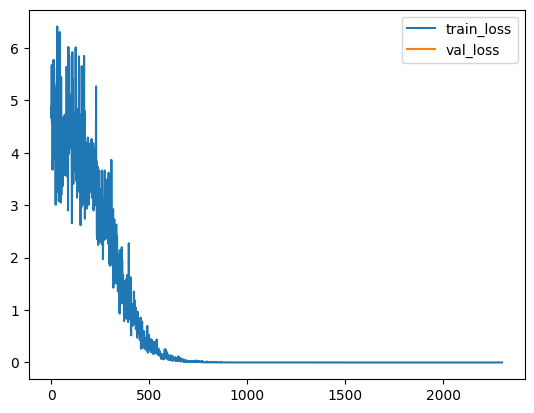

In [ ]:
pd.DataFrame(output1['history']).loc[:,['train_loss','val_loss']].plot()

# LSTM

## Many-to-one

In [70]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# -----------------------
# Synthetic multivariate time series (X_t in R^{Fx}, Y_t in R^{Fy})
# -----------------------
def make_ts(T=7000, Fx=5, Fy=3, noise_x=0.2, noise_y=0.1, seed=0):
  rng = np.random.default_rng(seed)

  # Stable-ish X dynamics: X_t = A X_{t-1} + eps
  A = rng.normal(0, 0.25, size=(Fx, Fx)).astype(np.float32)
  A *= 0.85 / (np.linalg.norm(A, ord=2) + 1e-6)

  X = np.zeros((T, Fx), dtype=np.float32)
  eps = rng.normal(0.0, noise_x, size=(T, Fx)).astype(np.float32)
  for t in range(1, T):
    X[t] = (A @ X[t - 1]) + eps[t]

  # Y depends on current/past X and past Y (ARX/NARX-ish)
  B0 = rng.normal(0, 0.8, size=(Fy, Fx)).astype(np.float32)  # X_t -> Y_t
  B1 = rng.normal(0, 0.4, size=(Fy, Fx)).astype(np.float32)  # X_{t-1} -> Y_t
  C1 = rng.normal(0, 0.3, size=(Fy, Fy)).astype(np.float32)  # Y_{t-1} -> Y_t
  C1 *= 0.75 / (np.linalg.norm(C1, ord=2) + 1e-6)

  Y = np.zeros((T, Fy), dtype=np.float32)
  ny = rng.normal(0.0, noise_y, size=(T, Fy)).astype(np.float32)
  for t in range(1, T):
    lin = (B0 @ X[t]) + (B1 @ X[t - 1]) + (C1 @ Y[t - 1])
    Y[t] = lin + 0.2 * np.tanh(lin) + ny[t]

  return X, Y

# -----------------------
# Windowed dataset:
#   input = X_{t-L+1:t} and (optionally) shifted Y history Y_{t-L+1:t-1}
#   target = Y_t
#
# include_past_y=True does NOT leak: we shift Y right and pad the first element.
# -----------------------
class WindowDataset(Dataset):
  def __init__(self, X, Y, seq_len=32, include_past_y=False):
    assert len(X) == len(Y)
    self.X = torch.tensor(X, dtype=torch.float32)  # (T, Fx)
    self.Y = torch.tensor(Y, dtype=torch.float32)  # (T, Fy)
    self.seq_len = seq_len
    self.include_past_y = include_past_y

  def __len__(self):
    return len(self.X) - self.seq_len + 1

  def __getitem__(self, idx):
    x_seq = self.X[idx:idx + self.seq_len]                 # (S, Fx)
    y_t = self.Y[idx + self.seq_len - 1]                   # (Fy,)

    if self.include_past_y:
      y_hist = self.Y[idx:idx + self.seq_len - 1]          # (S-1, Fy) past only
      pad = torch.zeros(1, y_hist.shape[1], dtype=y_hist.dtype)
      y_seq = torch.cat([pad, y_hist], dim=0)              # (S, Fy) shifted right
      inp = torch.cat([x_seq, y_seq], dim=-1)              # (S, Fx+Fy)
    else:
      inp = x_seq                                          # (S, Fx)

    return inp, y_t                                        # (S, Fin), (Fy,)

# -----------------------
# LSTM regressor: (B, S, Fin) -> (B, Fy)
# -----------------------
class LSTMRegressor(nn.Module):
  def __init__(self, in_features, out_features, hidden=64, num_layers=1, dropout=0.0):
    super().__init__()
    self.lstm = nn.LSTM(
      input_size=in_features,
      hidden_size=hidden,
      num_layers=num_layers,
      dropout=dropout if num_layers > 1 else 0.0,
      batch_first=True
    )
    self.head = nn.Linear(hidden, out_features)

  def forward(self, x):
    out, _ = self.lstm(x)     # (B, S, H)
    last = out[:, -1, :]      # (B, H)
    return self.head(last)    # (B, Fy)

In [71]:
T, Fx, Fy = 7000, 5, 3
seq_len = 32
include_past_y = False
epochs = 10
batch_size = 128
lr = 1e-3
seed = 0
early_stop_patience = 5
early_stop_tol = 0
eval_every = 100
n_steps = 100_000
weight_decay = 1e-5
loss_fn = nn.MSELoss()
torch.manual_seed(seed)
np.random.seed(seed)
in_features = Fx + (Fy if include_past_y else 0)
X, Y = make_ts(T=T, Fx=Fx, Fy=Fy, seed=seed)
X.shape, Y.shape

((7000, 5), (7000, 3))

In [72]:
# time split (no leakage across time)
split = int(0.8 * T)
X_tr, Y_tr = X[:split], Y[:split]
# keep alignment so first val window has enough history
X_va, Y_va = X[split - (seq_len - 1):], Y[split - (seq_len - 1):]

In [73]:
x,y=train_ds[1]
x.shape,y.shape

(torch.Size([32, 8]), torch.Size([3]))

In [74]:
train_data = WindowDataset(X_tr, Y_tr, seq_len=seq_len, include_past_y=include_past_y)
val_data = WindowDataset(X_va, Y_va, seq_len=seq_len, include_past_y=include_past_y)

model = LSTMRegressor(in_features=in_features, out_features=Fy, hidden=64)

output1 = fit_adam(model = model,
                   train_data = train_data,
                   val_data = val_data,
                   batch_size = batch_size,
                   early_stop_patience = early_stop_patience,
                   early_stop_tol = early_stop_tol,
                   eval_every = eval_every,
                   lr = lr,
                   weight_decay = weight_decay,
                   n_steps = n_steps,
                   loss_fn = loss_fn)

train:   0%|          | 0/100000 [00:00<?, ?step/s]

In [75]:
output1['model'](torch.tensor(X_va)[-seq_len:][None,:])

tensor([[ 0.1394,  2.6334, -0.3220]], grad_fn=<AddmmBackward0>)

In [76]:
out, (h_n, c_n) = output1['model'].lstm(torch.tensor(X_va)[-seq_len:][None,:])
out.shape, h_n.shape, c_n.shape

(torch.Size([1, 32, 64]), torch.Size([1, 1, 64]), torch.Size([1, 1, 64]))

## Many-to-Many

In [77]:
class WindowDatasetManyToMany(torch.utils.data.Dataset):
  def __init__(self, X, Y, seq_len=32, include_past_y=False):
    assert len(X) == len(Y)
    self.X = torch.tensor(X, dtype=torch.float32)  # (T, Fx)
    self.Y = torch.tensor(Y, dtype=torch.float32)  # (T, Fy)
    self.seq_len = seq_len
    self.include_past_y = include_past_y

  def __len__(self):
    return len(self.X) - self.seq_len + 1

  def __getitem__(self, idx):
    x_seq = self.X[idx:idx + self.seq_len]          # (S, Fx)
    y_seq = self.Y[idx:idx + self.seq_len]          # (S, Fy) targets for each step

    if self.include_past_y:
      # input gets shifted Y so it never sees the same-step label
      y_hist = self.Y[idx:idx + self.seq_len - 1]   # (S-1, Fy)
      pad = torch.zeros(1, y_hist.shape[1], dtype=y_hist.dtype)
      y_in = torch.cat([pad, y_hist], dim=0)        # (S, Fy)
      inp = torch.cat([x_seq, y_in], dim=-1)        # (S, Fx+Fy)
    else:
      inp = x_seq                                    # (S, Fx)

    return inp, y_seq

class LSTMManyToMany(nn.Module):
  def __init__(self, in_features, out_features, hidden=64, num_layers=1, dropout=0.0):
    super().__init__()
    self.lstm = nn.LSTM(
      input_size=in_features,
      hidden_size=hidden,
      num_layers=num_layers,
      dropout=dropout if num_layers > 1 else 0.0,
      batch_first=True
    )
    self.head = nn.Linear(hidden, out_features)

  def forward(self, x):
    out, _ = self.lstm(x)      # (B, S, H)
    return self.head(out)      # (B, S, Fy)


In [78]:
train_data = WindowDatasetManyToMany(X_tr, Y_tr, seq_len=seq_len, include_past_y=include_past_y)
val_data = WindowDatasetManyToMany(X_va, Y_va, seq_len=seq_len, include_past_y=include_past_y)

model = LSTMManyToMany(in_features=in_features, out_features=Fy, hidden=64)

output1 = fit_adam(model = model,
                   train_data = train_data,
                   val_data = val_data,
                   batch_size = batch_size,
                   early_stop_patience = early_stop_patience,
                   early_stop_tol = early_stop_tol,
                   eval_every = eval_every,
                   lr = lr,
                   weight_decay = weight_decay,
                   n_steps = n_steps,
                   loss_fn = loss_fn)

train:   0%|          | 0/100000 [00:00<?, ?step/s]

In [85]:
output1['model'](torch.tensor(X_va)[-seq_len:][None,:])[0][-1]

tensor([ 0.1676,  2.6193, -0.3453], grad_fn=<SelectBackward0>)

tensor([[-2.4063, -0.3422,  0.0459],
        [ 0.9373,  0.8944,  2.2563]])

In [ ]:
class LSTMCellScratch(nn.Module):

  #Single-layer LSTM cell implemented with explicit gate math.
  #Matches PyTorch LSTM gate order: (i, f, g, o).

  def __init__(self, input_size: int, hidden_size: int, scale: float):
    super().__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.scale = scale
    self.Wi = nn.Parameter(torch.normal(mean=torch.zeros(4*hidden_size, input_size), std=scale))
    self.Wh = nn.Parameter(torch.normal(mean=torch.zeros(4*hidden_size, hidden_size), std=scale))
    self.b = nn.Parameter(torch.normal(mean=torch.zeros(4*hidden_size, 1), std=scale))

  def forward(self, x_t: torch.Tensor, state):

    #x_t: (B, I)
    #state: (h_t, c_t), each (B, H)

    h_t, c_t = state
    i, f, g, o = (x_t@self.Wi.T + h_t@self.Wh.T + self.b.T).chunk(4, dim=-1)
    i, f, g, o = torch.sigmoid(i), torch.sigmoid(f), torch.tanh(g), torch.sigmoid(o)
    c_t = f * c_t + i * g
    h_t = o * torch.tanh(c_t)

    return (h_t, c_t)

class LSTMScratch(nn.Module):
  #Processes a full sequence with the scratch LSTM cell.

  def __init__(self, input_size: int, hidden_size: int, scale: float):
    super().__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.scale = scale
    self.cell = LSTMCellScratch(input_size, hidden_size, scale)

  def forward(self, x: torch.Tensor, state=None):

    #x: (B, S, I)
    #state: optional (h0, c0) each (B, H)

    #returns:
    #  out: (B, S, H)
    #  (hT, cT): final state

    B, S, _ = x.shape
    if state is None:
      h_t = x.new_zeros(B, self.hidden_size)
      c_t = x.new_zeros(B, self.hidden_size)
    else:
      h_t, c_t = state

    out = []
    for t in range(S):
      h_t, c_t = self.cell(x[:,t,:], (h_t, c_t))
      out.append(h_t)

    out = torch.stack(out, dim=1)

    return out, (h_t, c_t)

class LSTMRegressorScratch(nn.Module):
  def __init__(self, in_features: int, out_features: int, scale: float = 1e-3, hidden: int = 64):
    super().__init__()
    self.input_size = in_features
    self.output_size = out_features
    self.hidden_size = hidden
    self.scale = scale
    self.lstm = LSTMScratch(self.input_size, self.hidden_size, self.scale)
    self.linear = nn.Linear(self.hidden_size, self.output_size)

  def forward(self, x: torch.Tensor):
    _, state = self.lstm(x)
    return self.linear(state[0])

"""many-to-many
def forward(self, x: torch.Tensor):
    out, _ = self.lstm(x)          # (B, S, H)
    y_hat = self.linear(out)       # (B, S, out_features)  (Linear applies on last dim)
    return y_hat
"""


In [ ]:
"""
import math
import torch
import torch.nn as nn


class LSTMCellScratch(nn.Module):

  #Single-layer LSTM cell implemented with explicit gate math.
  #Matches PyTorch LSTM gate order: (i, f, g, o).

  def __init__(self, input_size: int, hidden_size: int, bias: bool = True):
    super().__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size

    # W_ih: (4H, I), W_hh: (4H, H)
    self.W_ih = nn.Parameter(torch.empty(4 * hidden_size, input_size))
    self.W_hh = nn.Parameter(torch.empty(4 * hidden_size, hidden_size))

    if bias:
      self.b_ih = nn.Parameter(torch.empty(4 * hidden_size))
      self.b_hh = nn.Parameter(torch.empty(4 * hidden_size))
    else:
      self.register_parameter("b_ih", None)
      self.register_parameter("b_hh", None)

    self.reset_parameters()

  def reset_parameters(self):
    # Similar spirit to PyTorch: uniform in [-k, k], k = 1/sqrt(H)
    k = 1.0 / math.sqrt(self.hidden_size)
    for p in self.parameters():
      nn.init.uniform_(p, -k, k)

  def forward(self, x_t: torch.Tensor, state):

    #x_t: (B, I)
    #state: (h_t, c_t), each (B, H)

    h_t, c_t = state

    gates = x_t @ self.W_ih.T + h_t @ self.W_hh.T
    if self.b_ih is not None:
      gates = gates + self.b_ih + self.b_hh

    i, f, g, o = gates.chunk(4, dim=-1)
    i = torch.sigmoid(i)
    f = torch.sigmoid(f)
    g = torch.tanh(g)
    o = torch.sigmoid(o)

    c_next = f * c_t + i * g
    h_next = o * torch.tanh(c_next)
    return h_next, c_next


class LSTMScratch(nn.Module):
  #Processes a full sequence with the scratch LSTM cell.

  def __init__(self, input_size: int, hidden_size: int, batch_first: bool = True):
    super().__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.batch_first = batch_first
    self.cell = LSTMCellScratch(input_size, hidden_size)

  def forward(self, x: torch.Tensor, state=None):

    #x: (B, S, I) if batch_first else (S, B, I)
    #state: optional (h0, c0) each (B, H)

    #returns:
    #  out: (B, S, H) if batch_first else (S, B, H)
    #  (hT, cT): final state

    if not self.batch_first:
      x = x.transpose(0, 1)  # -> (B, S, I)

    B, S, _ = x.shape
    if state is None:
      h_t = x.new_zeros(B, self.hidden_size)
      c_t = x.new_zeros(B, self.hidden_size)
    else:
      h_t, c_t = state

    outputs = []
    for t in range(S):
      h_t, c_t = self.cell(x[:, t, :], (h_t, c_t))
      outputs.append(h_t)

    out = torch.stack(outputs, dim=1)  # (B, S, H)

    if not self.batch_first:
      out = out.transpose(0, 1)  # -> (S, B, H)

    return out, (h_t, c_t)


class LSTMRegressorScratch(nn.Module):
  def __init__(self, in_features: int, out_features: int, hidden: int = 64):
    super().__init__()
    self.lstm = LSTMScratch(input_size=in_features, hidden_size=hidden, batch_first=True)
    self.head = nn.Linear(hidden, out_features)

  def forward(self, x: torch.Tensor):
    out, _ = self.lstm(x)      # out: (B, S, H)
    last = out[:, -1, :]       # (B, H)
    return self.head(last)     # (B, out_features)
"""

In [ ]:
class MLP(nn.Module):
  def __init__(self, d_model: int = 128):
    super().__init__()
    self.d_model = d_model
    self.mlp = nn.Sequential(
        nn.Linear(d_model, 4*d_model),
        nn.GELU(),
        nn.Linear(4*d_model, d_model)
        )

  def forward(self, x):
    return self.mlp(x)

class TransformerBlock(nn.Module):
  def __init__(self, d_model: int = 128, n_heads: int = 4):
    super().__init__()
    self.d_model = d_model
    self.n_heads = n_heads

    self.attn = nn.MultiheadAttention(self.d_model, self.n_heads, batch_first = True)
    self.ff = MLP(self.d_model)

  def forward(self, x: torch.Tensor):
    z, _ = self.attn(x, x, x)
    z = self.ff(z) + x
    return z

In [ ]:
import torch
import torch.nn as nn

class MLP(nn.Module):
  def __init__(self, d_model: int = 128, d_ff: int | None = None, dropout: float = 0.0):
    super().__init__()
    d_ff = d_ff or (4 * d_model)
    self.net = nn.Sequential(
      nn.Linear(d_model, d_ff),
      nn.GELU(),
      nn.Dropout(dropout),
      nn.Linear(d_ff, d_model),
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.net(x)

class TransformerBlock(nn.Module):
  def __init__(self, d_model: int = 128, n_heads: int = 4, dropout: float = 0.0):
    super().__init__()
    self.ln1 = nn.LayerNorm(d_model)
    self.ln2 = nn.LayerNorm(d_model)
    self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True, dropout=dropout)
    self.ff = MLP(d_model, dropout=dropout)
    self.drop = nn.Dropout(dropout)

  def forward(
    self,
    x: torch.Tensor,
    attn_mask: torch.Tensor | None = None,
    key_padding_mask: torch.Tensor | None = None,
  ) -> torch.Tensor:
    h = self.ln1(x)
    attn_out, _ = self.attn(
      h, h, h,
      attn_mask=attn_mask,
      key_padding_mask=key_padding_mask,
      need_weights=False,
    )
    x = x + self.drop(attn_out)

    h = self.ln2(x)
    x = x + self.drop(self.ff(h))
    return x

class Transformer(nn.Module):
  def __init__(
    self,
    n_vocab: int,
    len_seq: int,
    d_model: int = 128,
    n_heads: int = 4,
    n_layers: int = 2,
    dropout: float = 0.0,
  ):
    super().__init__()
    self.len_seq = len_seq
    self.emb = nn.Embedding(n_vocab, d_model)
    self.pos = nn.Embedding(len_seq, d_model)
    self.drop = nn.Dropout(dropout)
    self.blocks = nn.ModuleList([
      TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)
    ])
    self.ln_f = nn.LayerNorm(d_model)

  def forward(
    self,
    x: torch.Tensor,  # (B, S)
    attn_mask: torch.Tensor | None = None,
    key_padding_mask: torch.Tensor | None = None,
  ) -> torch.Tensor:
    B, S = x.shape
    if S > self.len_seq:
      raise ValueError(f"Sequence length S={S} exceeds len_seq={self.len_seq}")

    pos_ids = torch.arange(S, device=x.device)  # (S,)
    h = self.emb(x) + self.pos(pos_ids)[None, :, :]  # (B, S, D)
    h = self.drop(h)

    for blk in self.blocks:
      h = blk(h, attn_mask=attn_mask, key_padding_mask=key_padding_mask)

    return self.ln_f(h)


In [9]:
128/4

32.0



```
import math
from typing import Optional

import torch
import torch.nn as nn


class LearnedPositionalEncoding(nn.Module):
  def __init__(self, d_model: int, max_len: int = 4096, dropout: float = 0.0):
    super().__init__()
    self.max_len = max_len
    self.pos_emb = nn.Embedding(max_len, d_model)
    self.drop = nn.Dropout(dropout)

  def forward(self, x: torch.Tensor, pos_offset: int = 0) -> torch.Tensor:
    # x: (B, S, D)
    b, s, d = x.shape
    if s + pos_offset > self.max_len:
      raise ValueError(f"Sequence length {s} (+ offset {pos_offset}) exceeds max_len={self.max_len}.")
    pos = torch.arange(pos_offset, pos_offset + s, device=x.device)  # (S,)
    return self.drop(x + self.pos_emb(pos).unsqueeze(0))  # (B, S, D)


class TransformerEncoderLayerSimple(nn.Module):
  def __init__(
    self,
    d_model: int,
    n_heads: int,
    d_ff: int = 2048,
    dropout: float = 0.1,
    norm_first: bool = True
  ):
    super().__init__()
    self.norm_first = norm_first

    self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
    self.ff = nn.Sequential(
      nn.Linear(d_model, d_ff),
      nn.GELU(),
      nn.Dropout(dropout),
      nn.Linear(d_ff, d_model),
      nn.Dropout(dropout),
    )

    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.drop = nn.Dropout(dropout)

  def forward(
    self,
    x: torch.Tensor,
    key_padding_mask: Optional[torch.Tensor] = None,
    attn_mask: Optional[torch.Tensor] = None
  ) -> torch.Tensor:
    # x: (B, S, D)
    # key_padding_mask: (B, S) bool, True = padding (ignored)
    if self.norm_first:
      y = self.norm1(x)
      y, _ = self.attn(
        y, y, y,
        key_padding_mask=key_padding_mask,
        attn_mask=attn_mask,
        need_weights=False
      )
      x = x + self.drop(y)

      y = self.norm2(x)
      x = x + self.ff(y)
      return x
    else:
      y, _ = self.attn(
        x, x, x,
        key_padding_mask=key_padding_mask,
        attn_mask=attn_mask,
        need_weights=False
      )
      x = self.norm1(x + self.drop(y))
      x = self.norm2(x + self.ff(x))
      return x


class TransformerEncoderSimple(nn.Module):
  def __init__(
    self,
    d_model: int,
    n_heads: int,
    n_layers: int,
    d_ff: int = 2048,
    dropout: float = 0.1,
    norm_first: bool = True
  ):
    super().__init__()
    self.layers = nn.ModuleList([
      TransformerEncoderLayerSimple(
        d_model=d_model,
        n_heads=n_heads,
        d_ff=d_ff,
        dropout=dropout,
        norm_first=norm_first
      )
      for _ in range(n_layers)
    ])
    self.final_norm = nn.LayerNorm(d_model) if norm_first else nn.Identity()

  def forward(
    self,
    x: torch.Tensor,
    key_padding_mask: Optional[torch.Tensor] = None,
    attn_mask: Optional[torch.Tensor] = None
  ) -> torch.Tensor:
    for layer in self.layers:
      x = layer(x, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
    return self.final_norm(x)


class TransformerEncoderModel(nn.Module):
  """
  - token ids: set vocab_size, pass input_ids (B, S) long
  - continuous: set in_features, pass x (B, S, F) float
  """
  def __init__(
    self,
    d_model: int = 256,
    n_heads: int = 8,
    n_layers: int = 4,
    d_ff: int = 1024,
    dropout: float = 0.1,
    max_len: int = 4096,
    vocab_size: Optional[int] = None,
    in_features: Optional[int] = None
  ):
    super().__init__()
    if (vocab_size is None) == (in_features is None):
      raise ValueError("Set exactly one of vocab_size (token ids) or in_features (continuous inputs).")

    self.is_token_input = vocab_size is not None
    if self.is_token_input:
      self.embed = nn.Embedding(vocab_size, d_model)
    else:
      self.embed = nn.Linear(in_features, d_model)

    self.pos = LearnedPositionalEncoding(d_model, max_len=max_len, dropout=dropout)
    self.enc = TransformerEncoderSimple(
      d_model=d_model,
      n_heads=n_heads,
      n_layers=n_layers,
      d_ff=d_ff,
      dropout=dropout,
      norm_first=True
    )

  def forward(
    self,
    x: torch.Tensor,
    key_padding_mask: Optional[torch.Tensor] = None,
    pos_offset: int = 0
  ) -> torch.Tensor:
    h = self.embed(x)            # (B, S, D)
    h = self.pos(h, pos_offset)  # trainable positions
    h = self.enc(h, key_padding_mask=key_padding_mask)
    return h                     # (B, S, D)


# --- tiny usage ---

# Token ids
B, S, V = 2, 8, 1000
m = TransformerEncoderModel(vocab_size=V, d_model=128, n_heads=4, n_layers=2, d_ff=256, max_len=512)
input_ids = torch.randint(0, V, (B, S))
pad_mask = torch.zeros(B, S, dtype=torch.bool)
out = m(input_ids, key_padding_mask=pad_mask)  # (B, S, 128)

# Continuous features
B, S, F = 2, 12, 16
m2 = TransformerEncoderModel(in_features=F, d_model=128, n_heads=4, n_layers=2, d_ff=256, max_len=512)
x = torch.randn(B, S, F)
out2 = m2(x)  # (B, S, 128)

```



In [ ]:
"""""